In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from functools import lru_cache
from entsoe import EntsoePandasClient

In [12]:
API_TOKEN = "9af21e20-861e-41a0-873b-03c15cddf7c9"
client = EntsoePandasClient(api_key=API_TOKEN)

In [13]:
@lru_cache(maxsize=None)
def hole_lastdaten(client, art, kuerzel, start_iso, end_iso):
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    if art == "load":
        return client.query_load(kuerzel, start=start, end=end)
    if art == "generation":
        return client.query_generation(kuerzel, start=start, end=end)
    raise ValueError(f"Unbekannte Abfrageart: {art}")

def hole_load_daten(client, kuerzel, start, end):
    return hole_lastdaten(client, "load", kuerzel, start.isoformat(), end.isoformat())

def hole_generation_daten(client, kuerzel, start, end):
    return hole_lastdaten(client, "generation", kuerzel, start.isoformat(), end.isoformat())

In [14]:
laender = {
    "Deutschland": "DE",
    "Frankreich":  "FR",
    #"Spanien":     "ES",
    #"Italien":     "IT",
    #"Polen":       "PL",
    #"Norwegen":    "NO",
    #"Kroatien":    "HR"
}

start = pd.Timestamp("2023-01-01", tz="UTC")
end   = pd.Timestamp("2024-01-01", tz="UTC")

In [15]:
jahresdaten = {}

for land, kuerzel in laender.items():
    try:
        daten = hole_load_daten(client, kuerzel, start, end)
        gesamt = daten.sum()
        if hasattr(gesamt, 'item'):
            gesamt = gesamt.item()
        jahresdaten[land] = gesamt / 1_000_000
        print(f"{land}: {jahresdaten[land]:.2f} TWh")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

Deutschland: 1833.53 TWh
Frankreich: 425.45 TWh


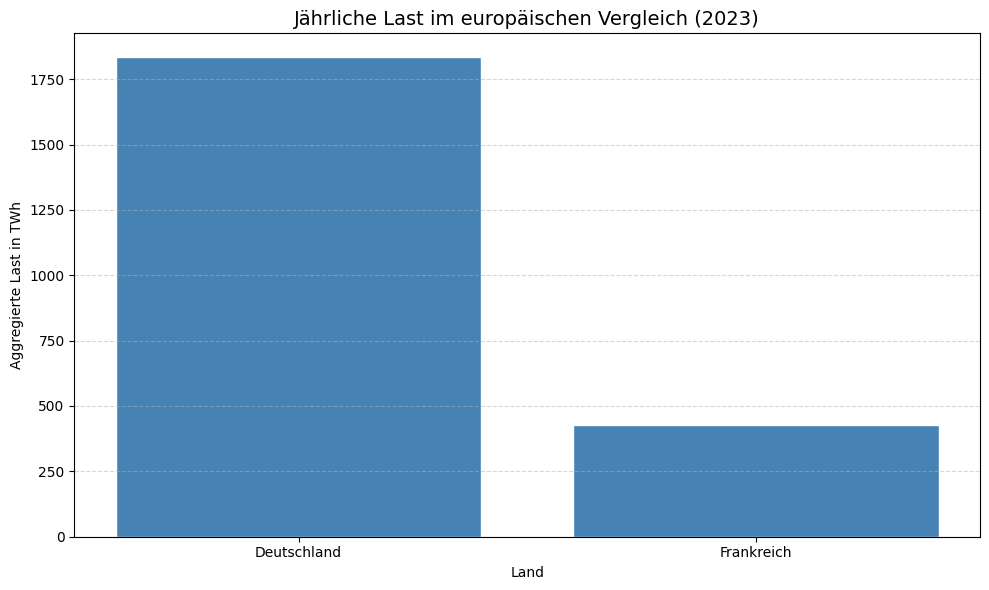

In [16]:
df = pd.DataFrame.from_dict(jahresdaten, orient="index", columns=["TWh"])
df = df.sort_values("TWh", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df.index, df["TWh"], color="steelblue", edgecolor="white")

ax.set_title("Jährliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Land")
ax.set_ylabel("Aggregierte Last in TWh")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastvergleich_2023.png")
plt.show()

In [17]:
# Monatliche Daten pro Land abrufen
monatsdaten = {}

for land, kuerzel in laender.items():
    try:
        daten = hole_load_daten(client, kuerzel, start, end)
        # Auf Monate aggregieren - kompatibel mit allen pandas Versionen
        monatlich = daten.resample("MS").sum() / 1_000_000  # TWh
        if hasattr(monatlich, 'squeeze'):
            monatlich = monatlich.squeeze()
        monatsdaten[land] = monatlich
        print(f"{land}: Daten geladen ✅")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

# Alle Länder in einen DataFrame zusammenführen
df_monate = pd.concat(monatsdaten, axis=1)
df_monate.columns = monatsdaten.keys()
df_monate = df_monate.sort_index()
df_monate = df_monate[df_monate.index.year == 2023]  # ← neu: nur Jahr 2023
df_monate.index = df_monate.index.strftime("%m.%Y")
df_monate = df_monate.round(2)
print(df_monate)

Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅
         Deutschland  Frankreich
01.2023       152.55       40.67
02.2023       163.51       39.29
03.2023       144.62       33.87
04.2023       145.29       30.46
05.2023       141.90       30.02
06.2023       145.01       31.29
07.2023       145.23       29.93
08.2023       143.25       30.55
09.2023       155.18       32.22
10.2023       164.36       38.14
11.2023       164.00       42.98
12.2023         0.16        0.05


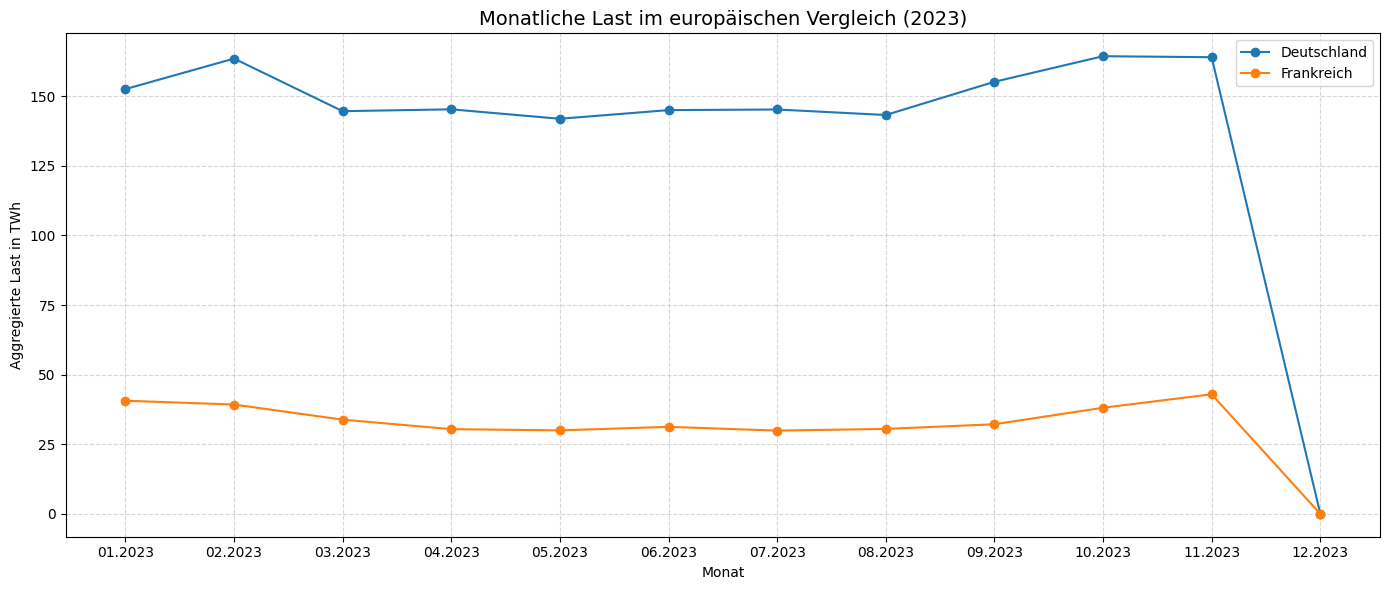

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

for land in df_monate.columns:
    ax.plot(df_monate.index, df_monate[land], marker="o", label=land)

ax.set_title("Monatliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Aggregierte Last in TWh")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastgang_linien_2023.png")
plt.show()

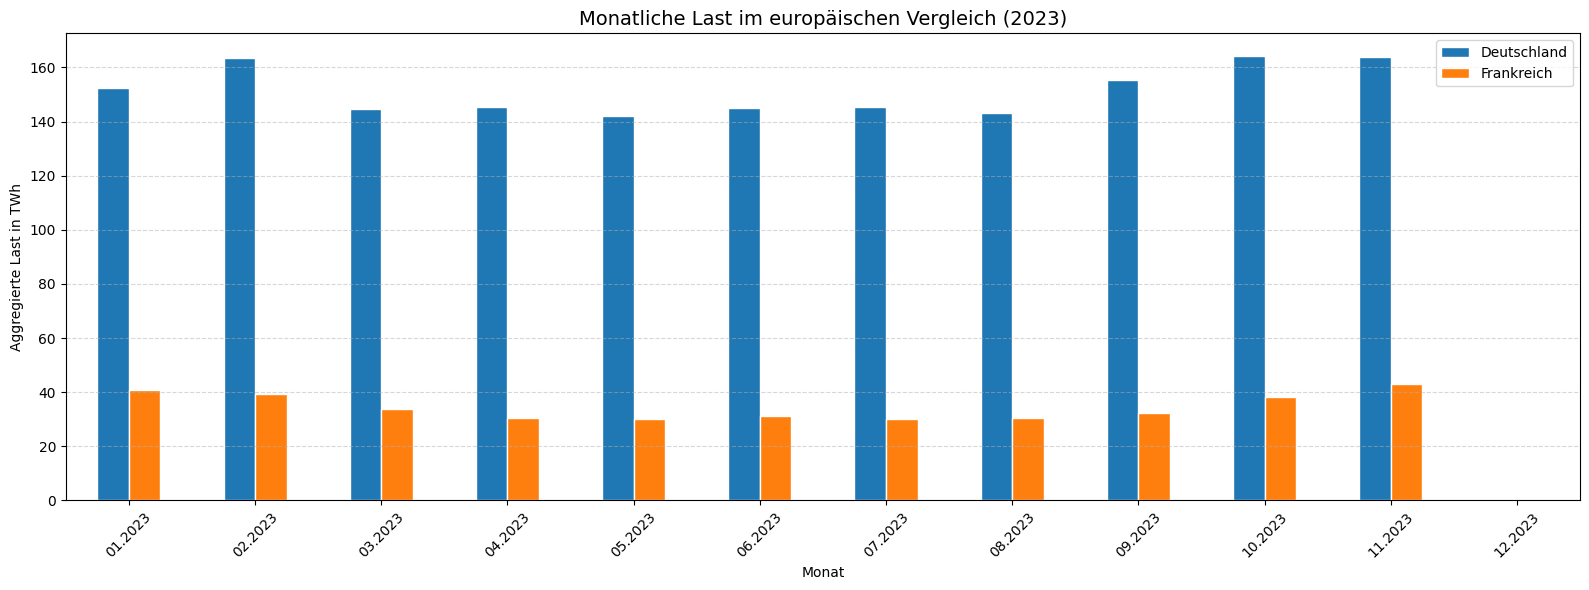

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))

df_monate.plot(kind="bar", ax=ax, edgecolor="white")

ax.set_title("Monatliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Aggregierte Last in TWh")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lastgang_balken_2023.png")
plt.show()

In [20]:
def lade_jahresdaten(client, laender, jahr):
    """
    Lädt monatliche Lastdaten für alle Länder eines bestimmten Jahres.
    """
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")
    
    monatsdaten = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_load_daten(client, kuerzel, start, end)
            monatlich = daten.resample("MS").sum() / 1_000_000
            if hasattr(monatlich, 'squeeze'):
                monatlich = monatlich.squeeze()
            monatsdaten[land] = monatlich
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")
    
    df = pd.concat(monatsdaten, axis=1)
    df.columns = monatsdaten.keys()
    df = df.sort_index()
    df = df[df.index.year == jahr]
    df.index = df.index.strftime("%m.%Y")
    df = df.round(2)
    return df

In [21]:
print("=== 2023 ===")
df_2023 = lade_jahresdaten(client, laender, 2023)

print("\n=== 2024 ===")
df_2024 = lade_jahresdaten(client, laender, 2024)

print("\n=== 2025 ===")
df_2025 = lade_jahresdaten(client, laender, 2025)

=== 2023 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== 2024 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== 2025 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


In [22]:
import os

jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

for jahr, df in jahre_dict.items():
    # Ordner erstellen, falls nicht vorhanden
    os.makedirs(str(jahr), exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for land in df.columns:
        ax.plot(df.index, df[land], marker="o", label=land)
    
    ax.set_title(f"Monatliche Last {jahr}", fontsize=13)
    ax.set_xlabel("Monat")
    ax.set_ylabel("Last in TWh")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle(f"Monatliche Last im europäischen Vergleich ({jahr})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{jahr}/lastgang.png")
    plt.close()

print("✅ Linienplots für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Linienplots für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [23]:
jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

for jahr, df in jahre_dict.items():
    # Ordner erstellen, falls nicht vorhanden
    os.makedirs(str(jahr), exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    df.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title(f"Monatliche Last {jahr}", fontsize=13)
    ax.set_xlabel("Monat")
    ax.set_ylabel("Last in TWh")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    
    plt.suptitle(f"Monatliche Last im europäischen Vergleich ({jahr})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{jahr}/lastgang_balken.png")
    plt.close()

print("✅ Balkendiagramme für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Balkendiagramme für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [24]:
def lade_aktuelle_woche(client, laender):
    """
    Lädt den stündlichen Lastverlauf der aktuellen Woche für alle Länder.
    """
    jetzt = pd.Timestamp.now(tz="UTC")
    wochenbeginn = jetzt.normalize() - pd.Timedelta(days=jetzt.weekday())  # Montag
    wochenende = jetzt

    wochendaten = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_load_daten(client, kuerzel, wochenbeginn, wochenende)
            if hasattr(daten, 'squeeze'):
                daten = daten.squeeze()
            wochendaten[land] = daten
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    df = pd.concat(wochendaten, axis=1)
    df.columns = wochendaten.keys()
    return df

In [25]:
print("=== Aktuelle Woche ===")
df_woche = lade_aktuelle_woche(client, laender)
print(df_woche)

=== Aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅
                           Deutschland  Frankreich
2026-05-04 00:00:00+00:00  39997.60540    36497.18
2026-05-04 00:15:00+00:00  39996.65872    35622.38
2026-05-04 00:30:00+00:00  39661.34180    34901.10
2026-05-04 00:45:00+00:00  39412.50173    34112.07
2026-05-04 01:00:00+00:00  39371.42452    33711.55
...                                ...         ...
2026-05-04 16:00:00+00:00  58122.22788    46361.23
2026-05-04 16:15:00+00:00  58208.28606    47009.13
2026-05-04 16:30:00+00:00  58719.09564    47946.41
2026-05-04 16:45:00+00:00  58664.98763    48671.86
2026-05-04 17:00:00+00:00  58817.07414         NaN

[69 rows x 2 columns]


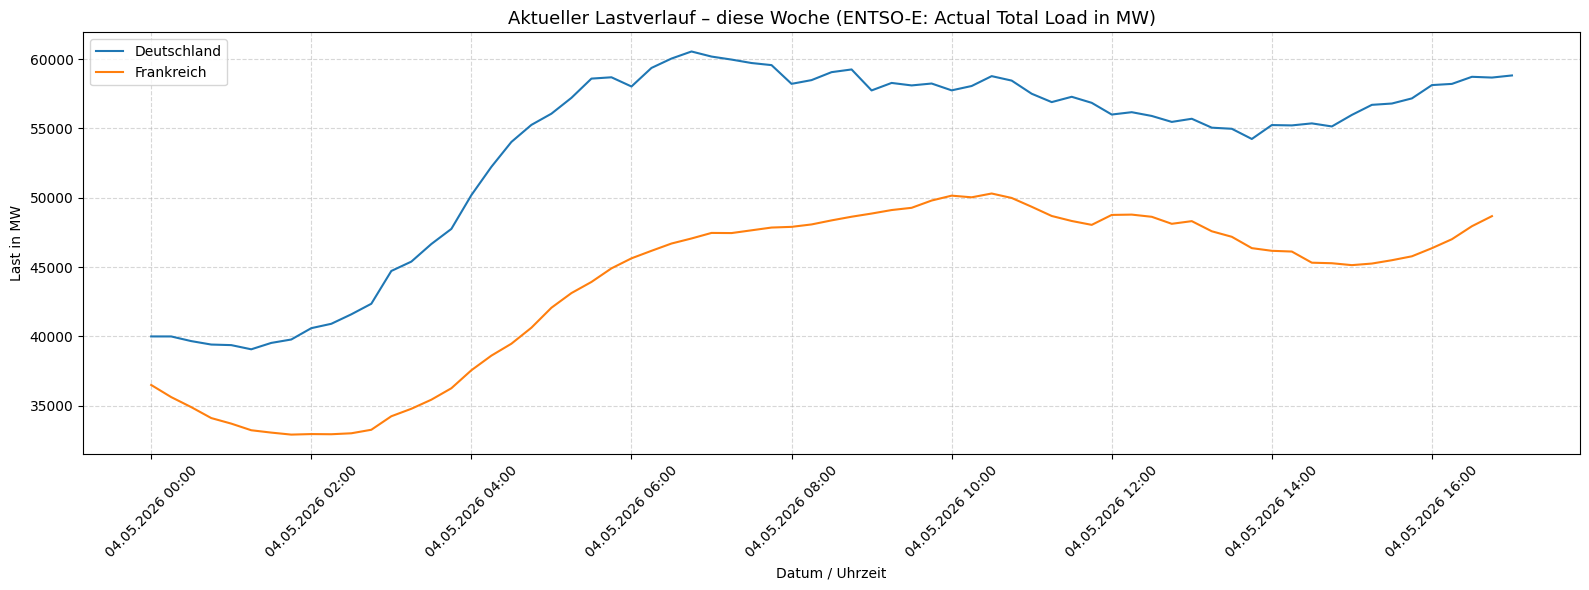

In [26]:
os.makedirs("aktuell", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))

for land in df_woche.columns:
    ax.plot(df_woche.index, df_woche[land], label=land)

ax.set_title("Aktueller Lastverlauf – diese Woche (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("aktuell/lastverlauf_woche.png")
plt.show()

In [27]:
def lade_aktueller_monat(client, laender):
    """
    Lädt den stündlichen Lastverlauf des aktuellen Monats für alle Länder.
    """
    jetzt = pd.Timestamp.now(tz="UTC")
    monatsbeginn = jetzt.normalize().replace(day=1)
    monatsende = jetzt

    monatsdaten_aktuell = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_load_daten(client, kuerzel, monatsbeginn, monatsende)
            if hasattr(daten, 'squeeze'):
                daten = daten.squeeze()
            monatsdaten_aktuell[land] = daten
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    df = pd.concat(monatsdaten_aktuell, axis=1)
    df.columns = monatsdaten_aktuell.keys()
    return df

=== Aktueller Monat ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


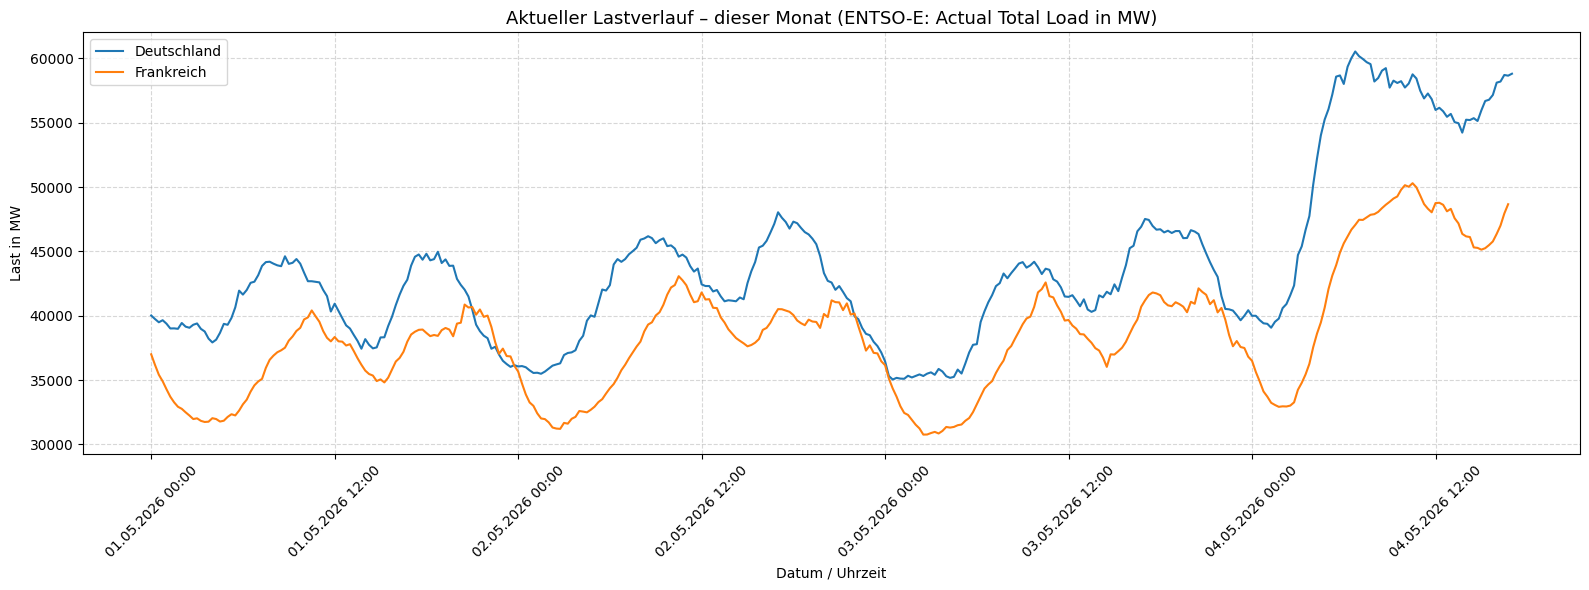

In [28]:
print("=== Aktueller Monat ===")
df_monat_aktuell = lade_aktueller_monat(client, laender)

os.makedirs("aktuell", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))

for land in df_monat_aktuell.columns:
    ax.plot(df_monat_aktuell.index, df_monat_aktuell[land], label=land)

ax.set_title("Aktueller Lastverlauf – dieser Monat (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("aktuell/lastverlauf_monat.png")
plt.show()

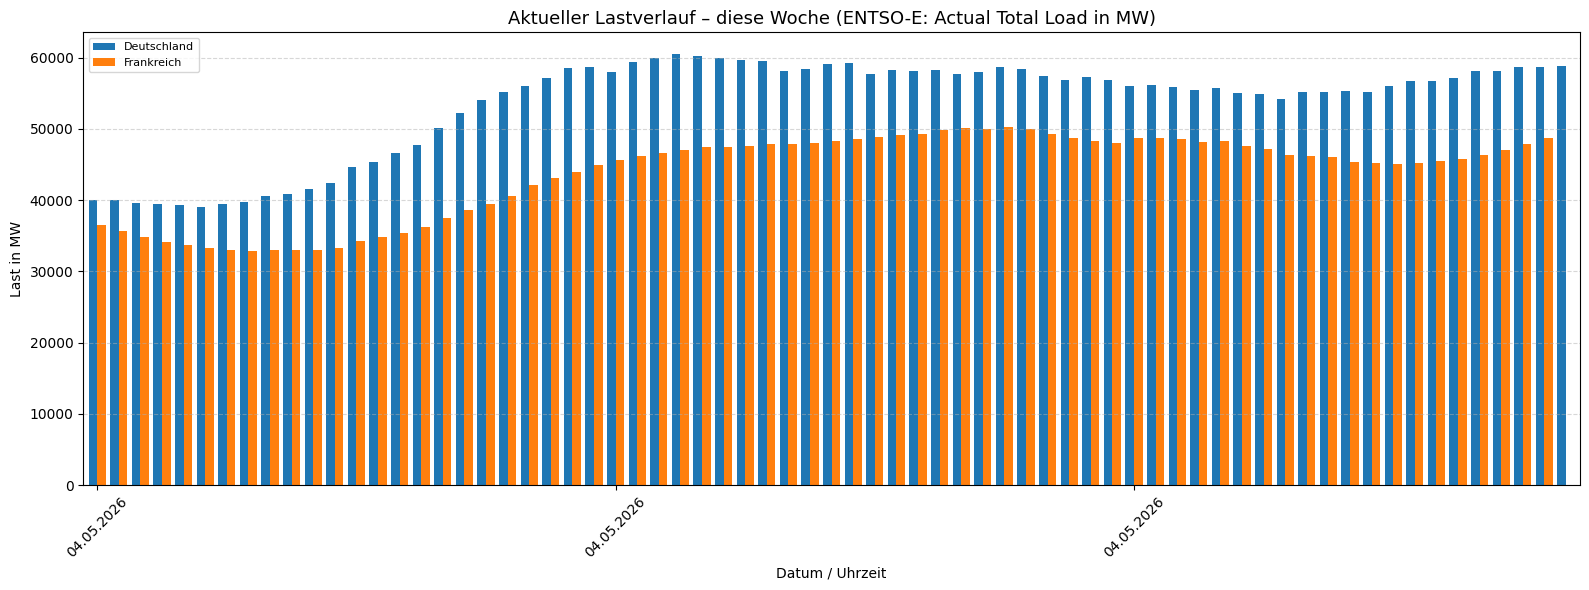

In [29]:
os.makedirs("aktuell", exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))

df_woche.plot(kind="bar", ax=ax, edgecolor="none", width=0.8)

ax.set_title("Aktueller Lastverlauf – diese Woche (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# X-Achse lesbarer machen
ticks = range(0, len(df_woche), 24)  # nur jeden Tag ein Label
ax.set_xticks(ticks)
ax.set_xticklabels([df_woche.index[i].strftime("%d.%m.%Y") for i in ticks], rotation=45)

plt.tight_layout()
plt.savefig("aktuell/lastverlauf_balken_woche.png")
plt.show()

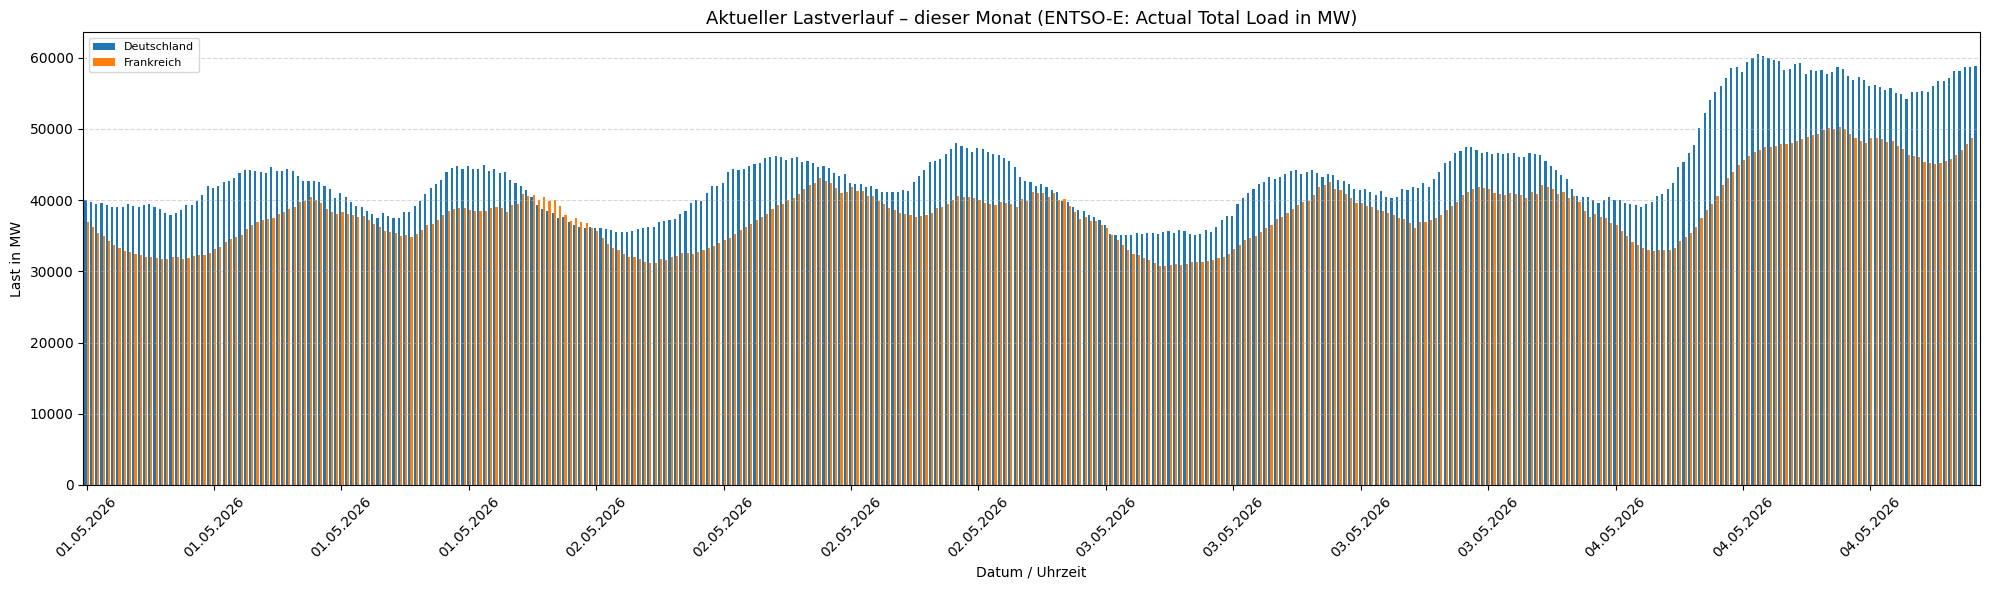

In [30]:
os.makedirs("aktuell", exist_ok=True)

fig, ax = plt.subplots(figsize=(20, 6))

df_monat_aktuell.plot(kind="bar", ax=ax, edgecolor="none", width=0.8)

ax.set_title("Aktueller Lastverlauf – dieser Monat (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# X-Achse lesbarer machen - nur jeden Tag ein Label
ticks = range(0, len(df_monat_aktuell), 24)
ax.set_xticks(ticks)
ax.set_xticklabels([df_monat_aktuell.index[i].strftime("%d.%m.%Y") for i in ticks], rotation=45)

plt.tight_layout()
plt.savefig("aktuell/lastverlauf_balken_monat.png")
plt.show()

In [31]:
def lade_generation_woche(client, laender):
    """
    Lädt die gesamte Stromerzeugung der aktuellen Woche für alle Länder.
    """
    jetzt = pd.Timestamp.now(tz="UTC")
    wochenbeginn = jetzt.normalize() - pd.Timedelta(days=jetzt.weekday())
    wochenende = jetzt

    generationdaten = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_generation_daten(client, kuerzel, wochenbeginn, wochenende)
            # Alle Erzeugungsarten summieren
            gesamt = daten.sum(axis=1)
            generationdaten[land] = gesamt
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    df = pd.concat(generationdaten, axis=1)
    df.columns = generationdaten.keys()
    return df

In [32]:
print("=== Last aktuelle Woche ===")
df_woche = lade_aktuelle_woche(client, laender)

print("\n=== Generation aktuelle Woche ===")
df_gen_woche = lade_generation_woche(client, laender)

=== Last aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== Generation aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


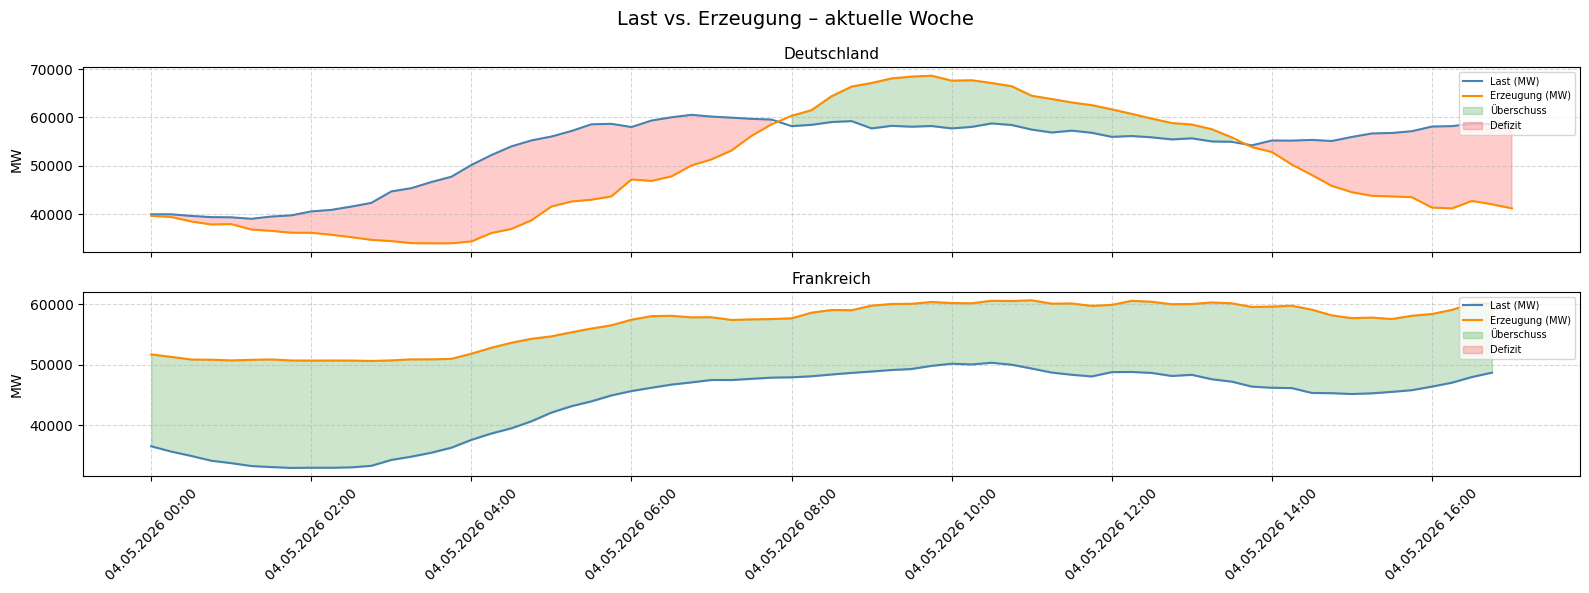

In [34]:
os.makedirs("aktuell", exist_ok=True)

fig, axes = plt.subplots(len(laender), 1, figsize=(16, len(laender) * 3), sharex=True)

for ax, land in zip(axes, laender.keys()):
    if land in df_woche.columns and land in df_gen_woche.columns:
        # Indizes abgleichen (beide auf den gleichen Index reindexieren)
        last_series = df_woche[land]
        gen_series = df_gen_woche[land].reindex(last_series.index, method='nearest')
        
        ax.plot(last_series.index, last_series, label="Last (MW)", color="steelblue")
        ax.plot(gen_series.index, gen_series, label="Erzeugung (MW)", color="darkorange")
        ax.fill_between(last_series.index, last_series, gen_series,
                        where=gen_series >= last_series,
                        alpha=0.2, color="green", label="Überschuss")
        ax.fill_between(last_series.index, last_series, gen_series,
                        where=gen_series < last_series,
                        alpha=0.2, color="red", label="Defizit")
        ax.set_title(land, fontsize=11)
        ax.set_ylabel("MW")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(linestyle="--", alpha=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))

plt.suptitle("Last vs. Erzeugung – aktuelle Woche", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("aktuell/last_vs_generation_woche.png")
plt.show()

In [35]:
def lade_erneuerbare(client, laender, jahr):
    """
    Berechnet den Anteil erneuerbarer Energien an der Gesamterzeugung pro Land.
    """
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")

    erneuerbare_typen = [
        "Solar", "Wind Onshore", "Wind Offshore",
        "Hydro Run-of-river and poundage", "Hydro Water Reservoir",
        "Geothermal", "Biomass"
    ]

    ergebnis = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_generation_daten(client, kuerzel, start, end)
            # MultiIndex-Spalten vereinfachen
            if isinstance(daten.columns, pd.MultiIndex):
                daten.columns = daten.columns.get_level_values(0)
            gesamt = daten.sum(axis=1).sum()
            erneuerbar = daten[[s for s in erneuerbare_typen if s in daten.columns]].sum(axis=1).sum()
            ergebnis[land] = round((erneuerbar / gesamt) * 100, 2)
            print(f"{land}: {ergebnis[land]}% erneuerbar")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    return pd.Series(ergebnis).sort_values(ascending=False)

print("=== Anteil Erneuerbare 2023 ===")
erneuerbare_2023 = lade_erneuerbare(client, laender, 2023)

fig, ax = plt.subplots(figsize=(10, 6))
farben = ["green" if v >= 50 else "steelblue" for v in erneuerbare_2023.values]
ax.bar(erneuerbare_2023.index, erneuerbare_2023.values, color=farben, edgecolor="white")
ax.axhline(50, color="red", linestyle="--", alpha=0.7, label="50% Schwelle")
ax.set_title("Anteil erneuerbarer Energien an der Erzeugung (2023)", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Anteil in %")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("erneuerbare_anteil_2023.png")
plt.show()

=== Anteil Erneuerbare 2023 ===


Connection Error, retrying in 10 seconds
Connection Error, retrying in 10 seconds


KeyboardInterrupt: 

=== Lastdeckungsgrad 2023 ===
Deutschland: 101.71% Lastdeckungsgrad
Frankreich: 113.55% Lastdeckungsgrad
Spanien: 113.47% Lastdeckungsgrad
Italien: 83.9% Lastdeckungsgrad
Polen: 92.27% Lastdeckungsgrad
Norwegen: 113.31% Lastdeckungsgrad
Kroatien: 28.64% Lastdeckungsgrad


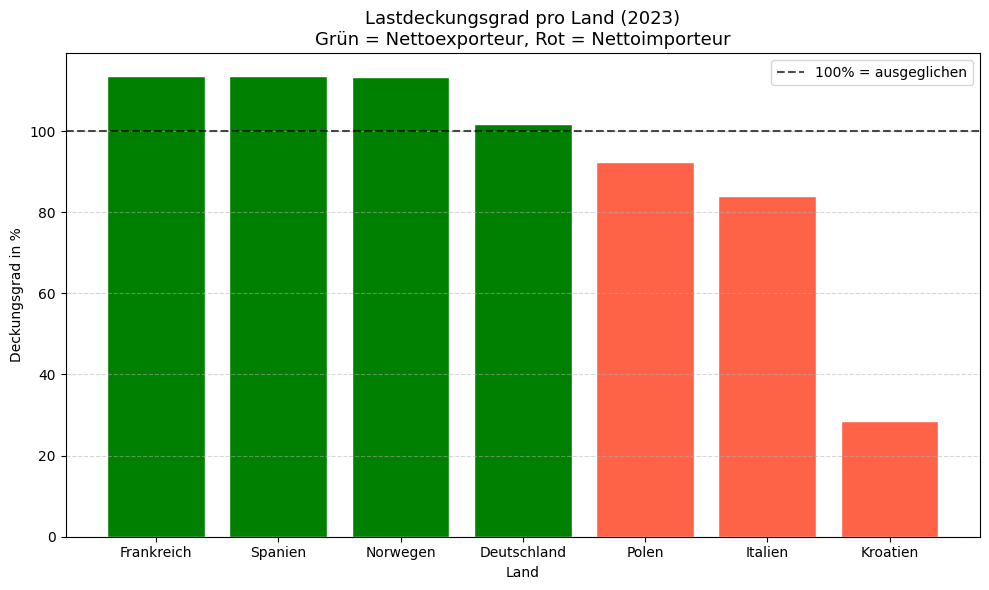

In [ ]:
def berechne_lastdeckungsgrad(client, laender, jahr):
    """
    Verhältnis Erzeugung / Last pro Land – über 100% = Nettoexporteur.
    """
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")

    ergebnis = {}
    for land, kuerzel in laender.items():
        try:
            last_daten = hole_load_daten(client, kuerzel, start, end)
            gen = hole_generation_daten(client, kuerzel, start, end)
            if isinstance(gen.columns, pd.MultiIndex):
                gen.columns = gen.columns.get_level_values(0)

            if isinstance(last_daten, pd.DataFrame):
                last = last_daten.sum().sum()
            else:
                last = last_daten.sum()

            if isinstance(gen, pd.DataFrame):
                erzeugung = gen.sum(axis=1).sum()
            else:
                erzeugung = gen.sum()

            if hasattr(last, 'item'):
                last = last.item()
            if last == 0:
                raise ZeroDivisionError("Last ist 0, Lastdeckungsgrad kann nicht berechnet werden")

            ergebnis[land] = round((erzeugung / last) * 100, 2)
            print(f"{land}: {ergebnis[land]}% Lastdeckungsgrad")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    return pd.Series(ergebnis).sort_values(ascending=False)

print("=== Lastdeckungsgrad 2023 ===")
deckungsgrad = berechne_lastdeckungsgrad(client, laender, 2023)

fig, ax = plt.subplots(figsize=(10, 6))
farben = ["green" if v >= 100 else "tomato" for v in deckungsgrad.values]
ax.bar(deckungsgrad.index, deckungsgrad.values, color=farben, edgecolor="white")
ax.axhline(100, color="black", linestyle="--", alpha=0.7, label="100% = ausgeglichen")
ax.set_title("Lastdeckungsgrad pro Land (2023)\nGrün = Nettoexporteur, Rot = Nettoimporteur", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Deckungsgrad in %")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("lastdeckungsgrad_2023.png")
plt.show()

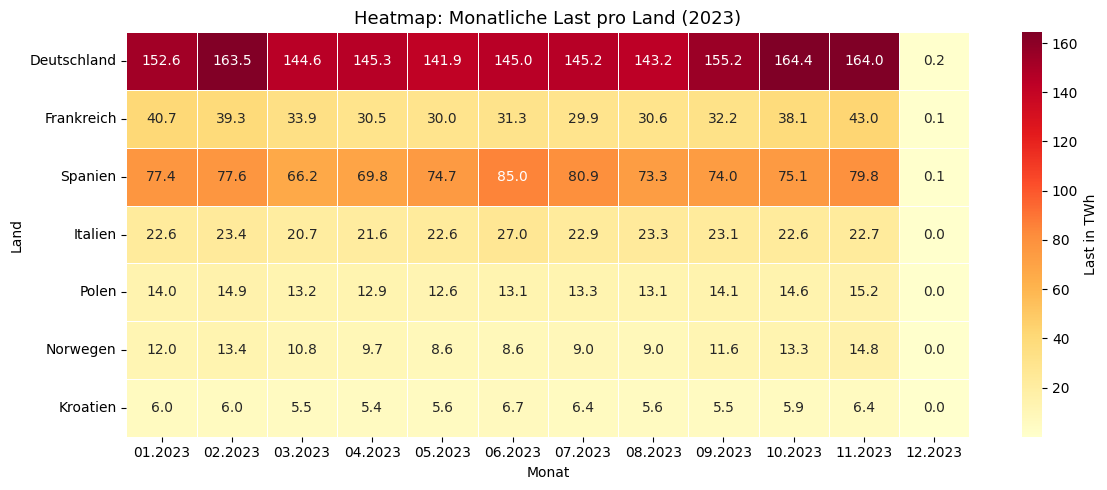

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))

# Transponieren: Länder als Zeilen, Monate als Spalten
sns.heatmap(
    df_2023.T,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Last in TWh"}
)

ax.set_title("Heatmap: Monatliche Last pro Land (2023)", fontsize=13)
ax.set_xlabel("Monat")
ax.set_ylabel("Land")
plt.tight_layout()
plt.savefig("heatmap_2023.png")
plt.show()

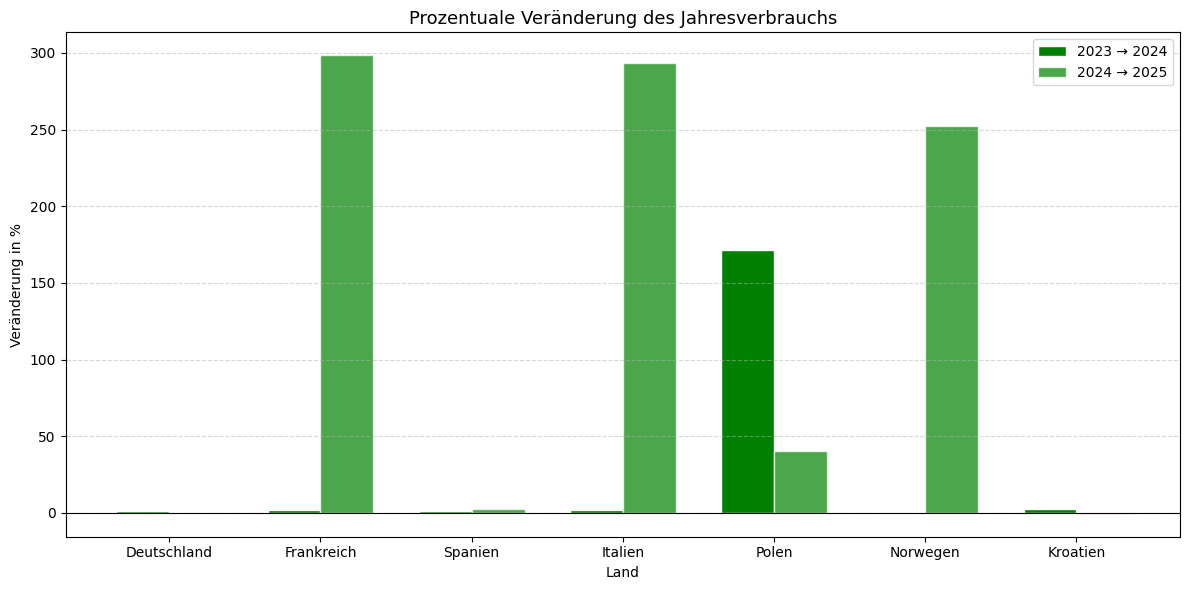

In [ ]:
os.makedirs("vergleich", exist_ok=True)

def berechne_veraenderung(df_vorjahr, df_aktuell):
    """
    Berechnet die prozentuale Veränderung des Jahresverbrauchs.
    """
    gesamt_vorjahr  = df_vorjahr.sum()
    gesamt_aktuell  = df_aktuell.sum()
    veraenderung    = ((gesamt_aktuell - gesamt_vorjahr) / gesamt_vorjahr) * 100
    return veraenderung.round(2)

veraenderung_23_24 = berechne_veraenderung(df_2023, df_2024)
veraenderung_24_25 = berechne_veraenderung(df_2024, df_2025)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(laender))
breite = 0.35

balken1 = ax.bar([i - breite/2 for i in x], veraenderung_23_24.values,
                  breite, label="2023 → 2024",
                  color=["green" if v >= 0 else "tomato" for v in veraenderung_23_24.values],
                  edgecolor="white")
balken2 = ax.bar([i + breite/2 for i in x], veraenderung_24_25.values,
                  breite, label="2024 → 2025",
                  color=["green" if v >= 0 else "tomato" for v in veraenderung_24_25.values],
                  edgecolor="white", alpha=0.7)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(laender.keys())
ax.set_title("Prozentuale Veränderung des Jahresverbrauchs", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Veränderung in %")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("vergleich/jahresveraenderung.png")
plt.show()

In [ ]:
print("=== Anteil Erneuerbare ===")

for jahr in [2023, 2024, 2025]:
    # Ordner erstellen, falls nicht vorhanden
    os.makedirs(str(jahr), exist_ok=True)
    
    print(f"\nGeneriere Diagramm für {jahr}...")
    erneuerbare = lade_erneuerbare(client, laender, jahr)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    erneuerbare.plot(kind="bar", ax=ax, edgecolor="white", color="steelblue")
    ax.axhline(50, color="red", linestyle="--", alpha=0.7, linewidth=2, label="50% Schwelle")
    ax.set_title(f"Anteil erneuerbarer Energien an der Erzeugung ({jahr})", fontsize=13)
    ax.set_xlabel("Land")
    ax.set_ylabel("Anteil in %")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 120)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{jahr}/erneuerbare_anteil.png")
    plt.close()

print("✅ Erneuerbare-Anteile für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

=== Anteil Erneuerbare ===

Generiere Diagramm für 2023...
Deutschland: 53.75% erneuerbar
Frankreich: 25.56% erneuerbar
Spanien: 49.51% erneuerbar
Italien: 40.13% erneuerbar
Polen: 25.72% erneuerbar
Norwegen: 97.43% erneuerbar
Kroatien: 65.72% erneuerbar

Generiere Diagramm für 2024...
Deutschland: 56.65% erneuerbar
Frankreich: 25.23% erneuerbar
Spanien: 54.61% erneuerbar
Italien: 45.0% erneuerbar
Polen: 28.13% erneuerbar
Norwegen: 97.09% erneuerbar
Kroatien: 65.53% erneuerbar

Generiere Diagramm für 2025...


Connection Error, retrying in 10 seconds


Deutschland: 57.04% erneuerbar
Frankreich: 24.57% erneuerbar
Spanien: 52.9% erneuerbar
Italien: 41.19% erneuerbar
Polen: 28.31% erneuerbar
Norwegen: 97.34% erneuerbar
Kroatien: 68.28% erneuerbar
✅ Erneuerbare-Anteile für 2023, 2024, 2025 abgespeichert


In [ ]:
print("=== Lastdeckungsgrad ===")

for jahr in [2023, 2024, 2025]:
    # Ordner erstellen, falls nicht vorhanden
    os.makedirs(str(jahr), exist_ok=True)
    
    print(f"\nGeneriere Diagramm für {jahr}...")
    deckungsgrad = berechne_lastdeckungsgrad(client, laender, jahr)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    deckungsgrad.plot(kind="bar", ax=ax, edgecolor="white", color="darkgreen")
    ax.axhline(100, color="black", linestyle="--", alpha=0.7, linewidth=2, label="100% = ausgeglichen")
    ax.set_title(f"Lastdeckungsgrad pro Land ({jahr})\nÜber 100% = Nettoexporteur", fontsize=13)
    ax.set_xlabel("Land")
    ax.set_ylabel("Deckungsgrad in %")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{jahr}/deckungsgrad.png")
    plt.close()

print("✅ Lastdeckungsgrad für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

=== Lastdeckungsgrad ===

Generiere Diagramm für 2023...
Deutschland: 101.71% Lastdeckungsgrad
Frankreich: 113.55% Lastdeckungsgrad
Spanien: 113.47% Lastdeckungsgrad
Italien: 83.9% Lastdeckungsgrad
Polen: 92.27% Lastdeckungsgrad
Norwegen: 113.31% Lastdeckungsgrad
Kroatien: 28.64% Lastdeckungsgrad

Generiere Diagramm für 2024...
Deutschland: 96.82% Lastdeckungsgrad
Frankreich: 136.84% Lastdeckungsgrad
Spanien: 111.64% Lastdeckungsgrad
Italien: 84.06% Lastdeckungsgrad
Polen: 99.21% Lastdeckungsgrad
Norwegen: 113.59% Lastdeckungsgrad
Kroatien: 74.8% Lastdeckungsgrad

Generiere Diagramm für 2025...
Deutschland: 96.74% Lastdeckungsgrad
Frankreich: 124.74% Lastdeckungsgrad
Spanien: 112.62% Lastdeckungsgrad
Italien: 81.13% Lastdeckungsgrad
Polen: 101.31% Lastdeckungsgrad
Norwegen: 108.94% Lastdeckungsgrad
Kroatien: 70.57% Lastdeckungsgrad
✅ Lastdeckungsgrad für 2023, 2024, 2025 abgespeichert


In [ ]:
jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

for jahr, df in jahre_dict.items():
    # Ordner erstellen, falls nicht vorhanden
    os.makedirs(str(jahr), exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    sns.heatmap(
        df.T,
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Last in TWh"}
    )
    
    ax.set_title(f"Heatmap: Monatliche Last pro Land ({jahr})", fontsize=13)
    ax.set_xlabel("Monat")
    ax.set_ylabel("Land")
    
    plt.tight_layout()
    plt.savefig(f"{jahr}/heatmap.png")
    plt.close()

print("✅ Heatmaps für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Heatmaps für 2023, 2024, 2025 abgespeichert
